# ML Pipeline: Predicting Citation Impact

**Objective**: Build a modular ML pipeline to predict `total_citations` for target author publications using multiple models and interpretability methods.

**Target Variable**: `total_citations in the first 2 years` (regression task)

**Dataset**: `filtered_TargetA_df_corr.csv` — Target authors as corresponding authors (~190 rows × 44 columns)

**Approach**:
1. **Baseline**: Linear & Negative Binomial Regression
2. **Main Models**: XGBoost, LightGBM, CatBoost (with 3 train-test strategies: random, time-based, stratified)
3. **Interpretability**: SHAP values on top of gradient boosted models
4. **Validation**: Random Forest as parallel model for feature importance cross-check

**Pipeline Structure**: Clear separation of concerns—load → prepare → baseline → main models → interpret → validate → summarize

In [34]:
## Section 1: Setup & Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Gradient boosted models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Interpretability
import shap

# Statsmodels for Negative Binomial Regression
import statsmodels.api as sm
from statsmodels.genmod.families import NegativeBinomial

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful")

✓ All imports successful


## Section 2: Data Loading & Inspection

In [35]:
# Load data
data_path = Path("../data/filtered_TargetA_df_corr.csv")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(2))
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nBasic statistics for numeric columns:")
print(df.describe())

Dataset shape: (391, 46)

First few rows:
                         article_id  \
0  https://openalex.org/W2942591112   
1  https://openalex.org/W2944794516   

                                               title publication_date  \
0  Excessive rainfall leads to maize yield loss o...       2019-04-29   
1  Integrating satellite and climate data to pred...       2019-05-11   

   publication_year     type    author_type queried_author  general_h_index  \
0              2019  article  Target_author          Kaiyu               70   
1              2019  article  Target_author          Kaiyu               70   

   general_i10_index author_position  ...  citations_year_5  citations_year_4  \
0                157          middle  ...             107.0             108.0   
1                157          middle  ...             110.0             104.0   

  citations_year_3 citations_year_2  citations_year_1 citations_year_0  \
0            101.0             78.0              46.0           

In [36]:
# Simple citation-rate feature from existing 3-year normalized citations
# As requested: citations per year = normalized_3y_cites_exact / 3

required_col = "normalized_3y_cites_exact"
new_col = "citations_per_year_3y"

if required_col not in df.columns:
    raise KeyError(f"Column '{required_col}' was not found in the dataset.")

# Keep NaN if present; only compute where values exist
df[new_col] = df[required_col] / 3.0

# Optional cleanup from previous approach (if these columns are present in memory)
old_exact_cols = [
    "citations_life_year_1_exact",
    "citations_life_year_2_exact",
    "citations_life_year_3_exact",
    "citations_first_3_life_years_exact",
]
df = df.drop(columns=[c for c in old_exact_cols if c in df.columns], errors="ignore")

print("✓ Added column:")
print(f"  - {new_col} = {required_col} / 3")
print("\nSample:")
print(df[["article_id", required_col, new_col]].head(10))

✓ Added column:
  - citations_per_year_3y = normalized_3y_cites_exact / 3

Sample:
                         article_id  normalized_3y_cites_exact  \
0  https://openalex.org/W2942591112                        156   
1  https://openalex.org/W2944794516                        178   
2  https://openalex.org/W2791592925                        126   
3  https://openalex.org/W3016616248                        191   
4  https://openalex.org/W4402262878                        369   
5  https://openalex.org/W3000098473                        153   
6  https://openalex.org/W2943472941                        133   
7  https://openalex.org/W4389113716                        340   
8  https://openalex.org/W3016661890                        133   
9  https://openalex.org/W2884351509                         42   

   citations_per_year_3y  
0              52.000000  
1              59.333333  
2              42.000000  
3              63.666667  
4             123.000000  
5              51.000000  
6


TARGET VARIABLE: normalized_3y_cites_exact
Data type: int64
Null count: 0
Statistics:
count    391.000000
mean      23.836317
std       36.300086
min        0.000000
25%        5.000000
50%       14.000000
75%       28.000000
max      369.000000
Name: normalized_3y_cites_exact, dtype: float64

Target distribution:


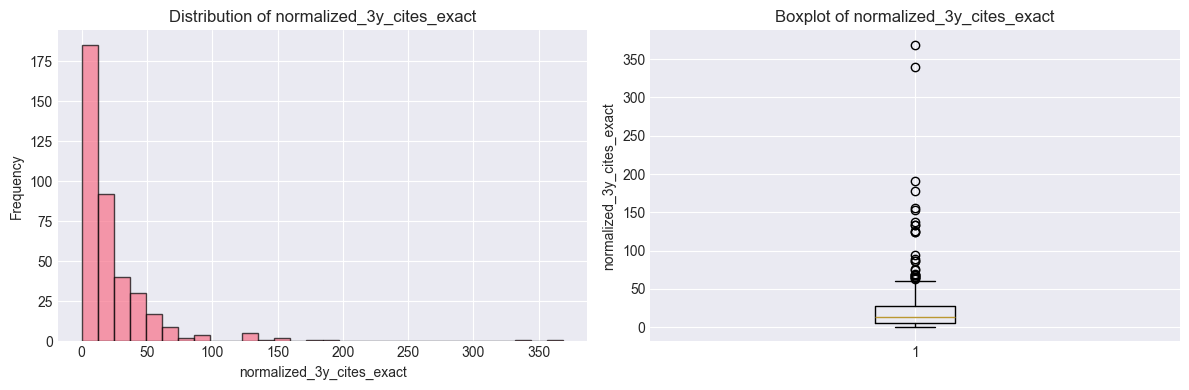

In [37]:
# Inspect target variable
TARGET = 'normalized_3y_cites_exact' 
# df[TARGET]=df[TARGET].fillna(0)  # Fill NaN with 0 for target variable
print(f"\n{'='*60}")
print(f"TARGET VARIABLE: {TARGET}")
print(f"{'='*60}")
print(f"Data type: {df[TARGET].dtype}")
print(f"Null count: {df[TARGET].isnull().sum()}")
print(f"Statistics:\n{df[TARGET].describe()}")
print(f"\nTarget distribution:")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Distribution of {TARGET}")
axes[1].boxplot(df[TARGET], vert=True)
axes[1].set_ylabel(TARGET)
axes[1].set_title(f"Boxplot of {TARGET}")
plt.tight_layout()
plt.show()

In [38]:
# Load and merge journal impact factor data
journal_if_path = Path("../data/JOURNAL_IF_2025.csv")
journal_if = pd.read_csv(journal_if_path)

print(f"\n{'='*60}")
print(f"JOURNAL IMPACT FACTOR DATA")
print(f"{'='*60}")
print(f"Impact factor dataset shape: {journal_if.shape}")
print(f"Columns: {journal_if.columns.tolist()}")
print(f"\nSample impact factors:")
print(journal_if.head(10))

# Merge impact factor data with main dataset
df = df.merge(journal_if, left_on='journal_display_name', right_on='journal_name', how='left')

# Check for unmatched journals
unmatched = df[df['impact_factor'].isnull()]['journal_display_name'].unique()
print(f"\n{len(unmatched)} journals not found in impact factor database:")
print(unmatched[:10])  # Show first 10

# Fill missing impact factors with 0 (journals without available IF)
df['impact_factor'] = df['impact_factor'].fillna(0)

print(f"\nImpact Factor Statistics:")
print(df['impact_factor'].describe())
print(f"\nDataset shape after adding impact_factor: {df.shape}")
print(f"✓ Journal impact factor data merged successfully")


JOURNAL IMPACT FACTOR DATA
Impact factor dataset shape: (376, 2)
Columns: ['journal_name', 'impact_factor']

Sample impact factors:
                                        journal_name  impact_factor
0                                              Joule      23.776846
1                 Nature Reviews Earth & Environment      19.357401
2                     Annual Review of Plant Biology      19.109589
3                              Nature Sustainability      18.643116
4       UTS ePRESS (University of Technology Sydney)      17.666667
5                                            Science      17.321177
6  CGSPace A Repository of Agricultural Research ...      16.285714
7                              Nature Communications      14.686409
8           Renewable and Sustainable Energy Reviews      13.907861
9                                            Biochar      13.420420

0 journals not found in impact factor database:
<StringArray>
[]
Length: 0, dtype: str

Impact Factor Statistics:
coun

## Section 3: Feature Preparation & Encoding

In [63]:
# Create a clean copy for feature preparation
df_model = df.copy()
eliminate_cols = ['article_id','author_position',
'journal_publisher','journal_name', 'topic_subfield', 'topic_field', 'topic_domain','keywords_very_specific', 
'keywords_specific', 'keywords_intermediate', 'keywords_broad', 'keywords_score_high','is_corresponding_author', 
'keywords_score_medium', 'keywords_score_low','percentile_min', 'percentile_max','publication_date',
'citations_year_6', 'citations_year_5', 'citations_year_4', 'citations_year_3', 'citations_year_2','is_oa', 
'citations_year_1', 'citations_year_0', 'citations_year_7', 'citations_year_8','author_type','sdgs',
"citations_per_year_3y","citation_norm_percentile",'total_citations']  # Columns to drop (IDs, redundant journal_name)
# Separate target from features
y = df_model[TARGET].values
X_data = df_model.drop(columns=[TARGET] + eliminate_cols)  # Drop target and specified columns

print(f"Initial features shape: {X_data.shape}")
print(f"\nFeature columns ({len(X_data.columns)}):")
print(X_data.columns.tolist())

# Identify categorical and numerical columns
categorical_cols = X_data.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

Initial features shape: (391, 15)

Feature columns (15):
['title', 'publication_year', 'type', 'queried_author', 'general_h_index', 'general_i10_index', 'n_authors', 'journal_display_name', 'oa_status', 'primary_topic', 'top_concepts', 'keywords', 'n_references', 'author_total_citations', 'impact_factor']

Categorical columns (8): ['title', 'type', 'queried_author', 'journal_display_name', 'oa_status', 'primary_topic', 'top_concepts', 'keywords']

Numerical columns (7): ['publication_year', 'general_h_index', 'general_i10_index', 'n_authors', 'n_references', 'author_total_citations', 'impact_factor']


PREDICTOR-TARGET CORRELATION DIAGNOSTICS

Top 15 predictors by absolute Pearson correlation with target:
               Feature  Pearson_r  Spearman_rho  Abs_Pearson_r
         impact_factor   0.380332      0.271455       0.380332
          n_references   0.344849      0.263160       0.344849
      publication_year  -0.236702     -0.521152       0.236702
             n_authors   0.218739      0.084227       0.218739
                  type   0.182566      0.046998       0.182566
       general_h_index   0.170607     -0.015427       0.170607
  journal_display_name   0.148036      0.093668       0.148036
        queried_author   0.127377      0.129807       0.127377
         primary_topic   0.058079      0.042342       0.058079
                 title   0.054242      0.078665       0.054242
author_total_citations   0.046055     -0.006951       0.046055
     general_i10_index  -0.042236     -0.129661       0.042236
          top_concepts   0.012513      0.052002       0.012513
             

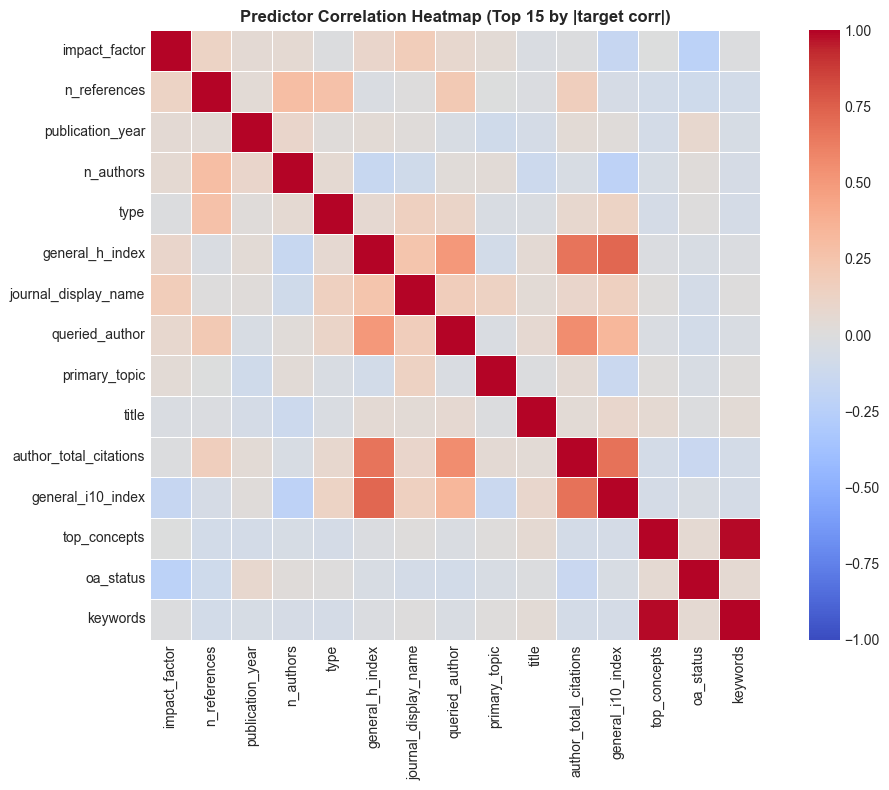


Top VIF values (multicollinearity check):
               Feature        VIF
          top_concepts 133.153678
              keywords 133.045695
       general_h_index  47.098618
      publication_year  40.267467
author_total_citations  24.521333
     general_i10_index  19.342082
        queried_author   5.653186
         impact_factor   5.430209
          n_references   5.083526
             n_authors   4.386719
         primary_topic   4.385727
                 title   4.043532
             oa_status   3.592078
  journal_display_name   3.301803
                  type   1.214532

Predictors with VIF > 10: 6
               Feature        VIF
          top_concepts 133.153678
              keywords 133.045695
       general_h_index  47.098618
      publication_year  40.267467
author_total_citations  24.521333
     general_i10_index  19.342082

Features marked for removal before modeling: ['top_concepts', 'keywords', 'general_h_index', 'publication_year', 'author_total_citations', 'gener

In [64]:
# Correlation diagnostics: predictor utility and co-dependence checks
print("=" * 80)
print("PREDICTOR-TARGET CORRELATION DIAGNOSTICS")
print("=" * 80)

# Build an analysis-only numeric matrix (do not modify X_data used later)
corr_X = X_data.copy()

# Numeric columns: coerce and impute median for stable correlations
for col in numerical_cols:
    corr_X[col] = pd.to_numeric(corr_X[col], errors="coerce")
    corr_X[col] = corr_X[col].fillna(corr_X[col].median())

# Categorical columns: encode to integer codes for correlation screening only
for col in categorical_cols:
    corr_X[col] = corr_X[col].astype(str).fillna("MISSING")
    corr_X[col], _ = pd.factorize(corr_X[col], sort=True)

# Ensure fully numeric matrix
corr_X = corr_X.apply(pd.to_numeric, errors="coerce").fillna(0)

# Target as numeric
y_corr = pd.to_numeric(df_model[TARGET], errors="coerce")
valid_rows = y_corr.notna()
corr_X_valid = corr_X.loc[valid_rows].copy()
y_corr_valid = y_corr.loc[valid_rows].copy()

# 1) Predictor vs target correlations (utility)
pearson_vals = corr_X_valid.corrwith(y_corr_valid, method="pearson")
spearman_vals = corr_X_valid.corrwith(y_corr_valid, method="spearman")

feature_target_corr = pd.DataFrame({
    "Feature": corr_X_valid.columns,
    "Pearson_r": pearson_vals.values,
    "Spearman_rho": spearman_vals.values,
})
feature_target_corr["Abs_Pearson_r"] = feature_target_corr["Pearson_r"].abs()
feature_target_corr = feature_target_corr.sort_values("Abs_Pearson_r", ascending=False)

print("\nTop 15 predictors by absolute Pearson correlation with target:")
print(feature_target_corr.head(15).to_string(index=False))

weak_predictors = feature_target_corr[feature_target_corr["Abs_Pearson_r"] < 0.05]
print(f"\nWeak linear-signal predictors (|r| < 0.05): {len(weak_predictors)}")
if len(weak_predictors) > 0:
    print(weak_predictors[["Feature", "Pearson_r"]].head(10).to_string(index=False))

# 2) Predictor co-dependence (pairwise feature correlation)
predictor_corr_abs = corr_X_valid.corr().abs()
upper = predictor_corr_abs.where(np.triu(np.ones(predictor_corr_abs.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Abs_r"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["Abs_r"] >= 0.80].sort_values("Abs_r", ascending=False)

print(f"\nHighly correlated predictor pairs (|r| >= 0.80): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print(high_corr_pairs.head(20).to_string(index=False))
else:
    print("No high-correlation predictor pairs found at this threshold.")

# 3) Heatmap of top utility predictors (helps visual inspection of co-dependence)
top_n_heatmap = 15
top_features = feature_target_corr.head(top_n_heatmap)["Feature"].tolist()
if len(top_features) > 1:
    plt.figure(figsize=(11, 8))
    sns.heatmap(
        corr_X_valid[top_features].corr(),
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
    )
    plt.title(f"Predictor Correlation Heatmap (Top {top_n_heatmap} by |target corr|)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# 4) VIF (Variance Inflation Factor) for multicollinearity screening
#    Rule of thumb: VIF > 5 moderate concern, VIF > 10 strong concern
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_input = corr_X_valid.copy()
# Remove near-constant columns to avoid numerical issues
vif_input = vif_input.loc[:, vif_input.nunique(dropna=False) > 1]

vif_df = pd.DataFrame({
    "Feature": vif_input.columns,
    "VIF": [variance_inflation_factor(vif_input.values, i) for i in range(vif_input.shape[1])],
}).sort_values("VIF", ascending=False)

print("\nTop VIF values (multicollinearity check):")
print(vif_df.head(15).to_string(index=False))

vif_threshold = 10
high_vif = vif_df[vif_df["VIF"] > vif_threshold]
vif_drop_features = high_vif["Feature"].tolist()

print(f"\nPredictors with VIF > {vif_threshold}: {len(high_vif)}")
if len(high_vif) > 0:
    print(high_vif.to_string(index=False))
    print(f"\nFeatures marked for removal before modeling: {vif_drop_features}")
else:
    print("No features exceed the VIF threshold.")

print("\nInterpretation guide:")
print("- Strong predictor utility: larger |Pearson_r| and/or |Spearman_rho|.")
print("- Potential co-dependence risk: many high-correlation feature pairs and high VIF.")
print("- For coefficient interpretation (linear/GLM), reducing high VIF is usually recommended.")
print("- For pure prediction with tree models, correlated predictors are often less problematic.")

In [65]:
# Apply VIF-based feature reduction (from previous diagnostics cell)
print("Applying VIF-based feature reduction...")
if "vif_drop_features" in globals() and len(vif_drop_features) > 0:
    drop_in_X = [c for c in vif_drop_features if c in X_data.columns]
    X_data = X_data.drop(columns=drop_in_X, errors="ignore")
    categorical_cols = [c for c in categorical_cols if c in X_data.columns]
    numerical_cols = [c for c in numerical_cols if c in X_data.columns]
    print(f"Dropped {len(drop_in_X)} high-VIF features: {drop_in_X}")
else:
    print("No high-VIF features found (or diagnostics cell not run). Proceeding without drops.")

# Handle missing values
print("\nHandling missing values...")
X_data = X_data.fillna(X_data.mean(numeric_only=True))  # Numerical: fill with mean
for col in categorical_cols:
    if X_data[col].isnull().any():
        X_data[col] = X_data[col].fillna(X_data[col].mode()[0])  # Categorical: fill with mode

print(f"Missing values after imputation:\n{X_data.isnull().sum().sum()}")

# Encode categorical features using LabelEncoder
# (XGBoost, LightGBM, CatBoost can handle categorical natively, but we'll encode for Linear/Forest models)
label_encoders = {}
X_data_encoded = X_data.copy()

if categorical_cols:
    print(f"\nEncoding categorical features...")
    for col in categorical_cols:
        le = LabelEncoder()
        X_data_encoded[col] = le.fit_transform(X_data_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"  {col}: {len(le.classes_)} unique values")

print(f"\nFinal feature matrix shape: {X_data_encoded.shape}")
print(f"Target shape: {y.shape}")

# Store for reference
X = X_data_encoded.values
feature_names = X_data_encoded.columns.tolist()
print(f"\nFeature names ready for modeling")

Applying VIF-based feature reduction...
Dropped 6 high-VIF features: ['top_concepts', 'keywords', 'general_h_index', 'publication_year', 'author_total_citations', 'general_i10_index']

Handling missing values...
Missing values after imputation:
0

Encoding categorical features...
  title: 378 unique values
  type: 5 unique values
  queried_author: 12 unique values
  journal_display_name: 96 unique values
  oa_status: 6 unique values
  primary_topic: 69 unique values

Final feature matrix shape: (391, 9)
Target shape: (391,)

Feature names ready for modeling


## Section 4: Train-Test Split Strategies

Three independent strategies to understand their trade-offs:
1. **Random 80/20**: Standard random split with stratification
2. **Time-Based**: Train on earlier years, test on recent years (temporal validation)
3. **Stratified**: Split stratified by primary_topic or key columns (group balance)

In [66]:
# Strategy 1: Random 80/20 Split
print("=" * 70)
print("STRATEGY 1: RANDOM 80/20 SPLIT")
print("=" * 70)
print("Pros: Standard, balanced sampling, reproducible")
print("Cons: May leak temporal patterns if publication year is important")
print("Use: General baseline comparison\n")

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

print(f"Training set size: {X_train_s1.shape[0]}")
print(f"Test set size: {X_test_s1.shape[0]}")
print(f"Target distribution in train: mean={y_train_s1.mean():.2f}, std={y_train_s1.std():.2f}")
print(f"Target distribution in test: mean={y_test_s1.mean():.2f}, std={y_test_s1.std():.2f}")

STRATEGY 1: RANDOM 80/20 SPLIT
Pros: Standard, balanced sampling, reproducible
Cons: May leak temporal patterns if publication year is important
Use: General baseline comparison

Training set size: 312
Test set size: 79
Target distribution in train: mean=22.79, std=36.52
Target distribution in test: mean=27.95, std=34.87


In [67]:
# Strategy 2: Time-Based Split
print("\n" + "=" * 70)
print("STRATEGY 2: TIME-BASED SPLIT (Earlier years → train, Recent years → test)")
print("=" * 70)
print("Pros: Tests forward prediction; avoids data leakage; realistic scenario")
print("Cons: May imbalance class distributions; fewer recent samples")
print("Use: Validate model's ability to predict future citations\n")

# Get publication_year column (index in original data)
publication_year_col_idx = df_model.columns.get_loc('publication_year')
publication_year = df_model['publication_year'].values

# Split: older years (80%) for train, recent years (20%) for test
median_year = np.percentile(publication_year, 80)
train_mask_s2 = publication_year <= median_year
test_mask_s2 = publication_year > median_year

X_train_s2 = X[train_mask_s2]
X_test_s2 = X[test_mask_s2]
y_train_s2 = y[train_mask_s2]
y_test_s2 = y[test_mask_s2]

print(f"Split threshold year: {median_year:.0f}")
print(f"Training set size: {X_train_s2.shape[0]} (years ≤ {median_year:.0f})")
print(f"Test set size: {X_test_s2.shape[0]} (years > {median_year:.0f})")
print(f"Target distribution in train: mean={y_train_s2.mean():.2f}, std={y_train_s2.std():.2f}")
print(f"Target distribution in test: mean={y_test_s2.mean():.2f}, std={y_test_s2.std():.2f}")


STRATEGY 2: TIME-BASED SPLIT (Earlier years → train, Recent years → test)
Pros: Tests forward prediction; avoids data leakage; realistic scenario
Cons: May imbalance class distributions; fewer recent samples
Use: Validate model's ability to predict future citations

Split threshold year: 2024
Training set size: 329 (years ≤ 2024)
Test set size: 62 (years > 2024)
Target distribution in train: mean=27.87, std=38.17
Target distribution in test: mean=2.45, std=3.77


In [68]:
# Strategy 3: Stratified Split (by primary_topic or author_type)
print("\n" + "=" * 70)
print("STRATEGY 3: STRATIFIED SPLIT (By primary_topic for group balance)")
print("=" * 70)
print("Pros: Ensures balanced representation of key groups in train/test")
print("Cons: No temporal validation; may overfit to group patterns")
print("Use: Confirm feature importance generalizes across publication topics\n")

# Check which column to use for stratification
stratify_col =  'author_type'
stratify_vector = df_model[stratify_col].values

# Create stratified split
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=stratify_vector
)

print(f"Stratification column: {stratify_col}")
print(f"Training set size: {X_train_s3.shape[0]}")
print(f"Test set size: {X_test_s3.shape[0]}")
print(f"Target distribution in train: mean={y_train_s3.mean():.2f}, std={y_train_s3.std():.2f}")
print(f"Target distribution in test: mean={y_test_s3.mean():.2f}, std={y_test_s3.std():.2f}")

print(f"\nStratification check - {stratify_col} distribution in train set:")
unique_vals, counts = np.unique(stratify_vector, return_counts=True)
print(f"  Unique values: {dict(zip(unique_vals, counts))}")
print(f"✓ All three train-test strategies ready")


STRATEGY 3: STRATIFIED SPLIT (By primary_topic for group balance)
Pros: Ensures balanced representation of key groups in train/test
Cons: No temporal validation; may overfit to group patterns
Use: Confirm feature importance generalizes across publication topics

Stratification column: author_type
Training set size: 312
Test set size: 79
Target distribution in train: mean=25.06, std=38.55
Target distribution in test: mean=19.00, std=24.64

Stratification check - author_type distribution in train set:
  Unique values: {'Target_author': np.int64(391)}
✓ All three train-test strategies ready


## Section 5: Baseline Models (Linear & Negative Binomial Regression)

**Strategy**: Use Strategy 1 (Random 80/20 split) for baseline comparison.

In [69]:
print("=" * 70)
print("BASELINE 1: LINEAR REGRESSION")
print("=" * 70)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_s1, y_train_s1)

# Predict
y_pred_lr = lr_model.predict(X_test_s1)

# Evaluate
mae_lr = mean_absolute_error(y_test_s1, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_s1, y_pred_lr))
r2_lr = r2_score(y_test_s1, y_pred_lr)

print(f"MAE:  {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")
print(f"\nTop 5 most important features (by absolute coefficient):")
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
print(coef_df.nlargest(5, 'Abs_Coefficient')[['Feature', 'Coefficient']])

BASELINE 1: LINEAR REGRESSION
MAE:  20.3306
RMSE: 33.3823
R²:   0.0834

Top 5 most important features (by absolute coefficient):
         Feature  Coefficient
1           type     4.330053
8  impact_factor     4.056195
5      oa_status     2.648364
3      n_authors     1.272083
7   n_references     0.269617


In [70]:
# Baseline 2: Negative Binomial Regression (statsmodels)
print("\n" + "=" * 70)
print("BASELINE 2: NEGATIVE BINOMIAL REGRESSION")
print("=" * 70)

try:
    # Add constant for statsmodels
    X_train_nb = sm.add_constant(X_train_s1)
    X_test_nb = sm.add_constant(X_test_s1)
    
    # Fit Negative Binomial
    nb_model = sm.GLM(y_train_s1, X_train_nb, family=NegativeBinomial()).fit()
    
    # Predict
    y_pred_nb = nb_model.predict(X_test_nb)
    
    # Evaluate
    mae_nb = mean_absolute_error(y_test_s1, y_pred_nb)
    rmse_nb = np.sqrt(mean_squared_error(y_test_s1, y_pred_nb))
    
    # R² for GLM
    residuals_nb = y_test_s1 - y_pred_nb
    ss_res_nb = np.sum(residuals_nb**2)
    ss_tot_nb = np.sum((y_test_s1 - y_test_s1.mean())**2)
    r2_nb = 1 - (ss_res_nb / ss_tot_nb)
    
    print(f"MAE:  {mae_nb:.4f}")
    print(f"RMSE: {rmse_nb:.4f}")
    print(f"R²:   {r2_nb:.4f}")
    print(f"\nModel Summary (top coefficients):")
    print(nb_model.summary().tables[1].data[:6])
    
except Exception as e:
    print(f"⚠️  Negative Binomial fit warning (may need adjustment): {e}")
    mae_nb = np.inf
    rmse_nb = np.inf
    r2_nb = -np.inf
    y_pred_nb = None


BASELINE 2: NEGATIVE BINOMIAL REGRESSION
MAE:  18.4583
RMSE: 32.4565
R²:   0.1335

Model Summary (top coefficients):
[['', 'coef', 'std err', 'z', 'P>|z|', '[0.025', '0.975]'], ['const', '    0.9921', '    0.260', '    3.811', ' 0.000', '    0.482', '    1.502'], ['x1', '    0.0011', '    0.001', '    2.071', ' 0.038', ' 5.91e-05', '    0.002'], ['x2', '   -0.0067', '    0.069', '   -0.097', ' 0.923', '   -0.142', '    0.129'], ['x3', '    0.0328', '    0.020', '    1.618', ' 0.106', '   -0.007', '    0.072'], ['x4', '    0.0225', '    0.012', '    1.831', ' 0.067', '   -0.002', '    0.047']]


In [71]:
# Baseline Comparison Table
print("\n" + "=" * 70)
print("BASELINE MODELS COMPARISON")
print("=" * 70)

baseline_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Negative Binomial'],
    'MAE': [mae_lr, mae_nb],
    'RMSE': [rmse_lr, rmse_nb],
    'R²': [r2_lr, r2_nb]
})

print(baseline_results.to_string(index=False))
print(f"\n✓ Baseline models complete")


BASELINE MODELS COMPARISON
            Model       MAE      RMSE       R²
Linear Regression 20.330642 33.382340 0.083395
Negative Binomial 18.458319 32.456463 0.133535

✓ Baseline models complete


## Section 6: Main Models (XGBoost, LightGBM, CatBoost)

**Strategy**: Train each model on all 3 train-test splits independently to compare their performance across different data scenarios.

In [72]:
# Utility function to evaluate and store model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, strategy_name):
    """
    Evaluate a model and return metrics dictionary
    """
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return {
        'Model': model_name,
        'Strategy': strategy_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Model_Object': model,
        'Predictions': y_pred
    }

# Dictionary to store all model results
model_results = []

print("=" * 70)
print("MAIN MODEL 1: XGBOOST REGRESSOR (on all 3 strategies)")
print("=" * 70)

MAIN MODEL 1: XGBOOST REGRESSOR (on all 3 strategies)


In [73]:
# XGBoost on Strategy 1: Random Split
print("\nStrategy 1: Random 80/20 Split")
xgb_s1 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_s1.fit(X_train_s1, y_train_s1)
result_xgb_s1 = evaluate_model(xgb_s1, X_train_s1, X_test_s1, y_train_s1, y_test_s1, 'XGBoost', 'Random 80/20')
model_results.append(result_xgb_s1)
print(f"  MAE: {result_xgb_s1['MAE']:.4f}, RMSE: {result_xgb_s1['RMSE']:.4f}, R²: {result_xgb_s1['R²']:.4f}")

# XGBoost on Strategy 2: Time-Based Split
print("\nStrategy 2: Time-Based Split")
xgb_s2 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_s2.fit(X_train_s2, y_train_s2)
result_xgb_s2 = evaluate_model(xgb_s2, X_train_s2, X_test_s2, y_train_s2, y_test_s2, 'XGBoost', 'Time-Based')
model_results.append(result_xgb_s2)
print(f"  MAE: {result_xgb_s2['MAE']:.4f}, RMSE: {result_xgb_s2['RMSE']:.4f}, R²: {result_xgb_s2['R²']:.4f}")

# XGBoost on Strategy 3: Stratified Split
print("\nStrategy 3: Stratified Split")
xgb_s3 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_s3.fit(X_train_s3, y_train_s3)
result_xgb_s3 = evaluate_model(xgb_s3, X_train_s3, X_test_s3, y_train_s3, y_test_s3, 'XGBoost', 'Stratified')
model_results.append(result_xgb_s3)
print(f"  MAE: {result_xgb_s3['MAE']:.4f}, RMSE: {result_xgb_s3['RMSE']:.4f}, R²: {result_xgb_s3['R²']:.4f}")

print("\n✓ XGBoost training complete on all 3 strategies")


Strategy 1: Random 80/20 Split
  MAE: 23.0372, RMSE: 38.7719, R²: -0.2365

Strategy 2: Time-Based Split
  MAE: 28.4241, RMSE: 38.3803, R²: -102.6231

Strategy 3: Stratified Split
  MAE: 18.5159, RMSE: 29.0802, R²: -0.3930

✓ XGBoost training complete on all 3 strategies


In [74]:
print("\n" + "=" * 70)
print("MAIN MODEL 2: LIGHTGBM REGRESSOR (on all 3 strategies)")
print("=" * 70)

# LightGBM on Strategy 1: Random Split
print("\nStrategy 1: Random 80/20 Split")
lgb_s1 = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_s1.fit(X_train_s1, y_train_s1)
result_lgb_s1 = evaluate_model(lgb_s1, X_train_s1, X_test_s1, y_train_s1, y_test_s1, 'LightGBM', 'Random 80/20')
model_results.append(result_lgb_s1)
print(f"  MAE: {result_lgb_s1['MAE']:.4f}, RMSE: {result_lgb_s1['RMSE']:.4f}, R²: {result_lgb_s1['R²']:.4f}")

# LightGBM on Strategy 2: Time-Based Split
print("\nStrategy 2: Time-Based Split")
lgb_s2 = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_s2.fit(X_train_s2, y_train_s2)
result_lgb_s2 = evaluate_model(lgb_s2, X_train_s2, X_test_s2, y_train_s2, y_test_s2, 'LightGBM', 'Time-Based')
model_results.append(result_lgb_s2)
print(f"  MAE: {result_lgb_s2['MAE']:.4f}, RMSE: {result_lgb_s2['RMSE']:.4f}, R²: {result_lgb_s2['R²']:.4f}")

# LightGBM on Strategy 3: Stratified Split
print("\nStrategy 3: Stratified Split")
lgb_s3 = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_s3.fit(X_train_s3, y_train_s3)
result_lgb_s3 = evaluate_model(lgb_s3, X_train_s3, X_test_s3, y_train_s3, y_test_s3, 'LightGBM', 'Stratified')
model_results.append(result_lgb_s3)
print(f"  MAE: {result_lgb_s3['MAE']:.4f}, RMSE: {result_lgb_s3['RMSE']:.4f}, R²: {result_lgb_s3['R²']:.4f}")

print("\n✓ LightGBM training complete on all 3 strategies")


MAIN MODEL 2: LIGHTGBM REGRESSOR (on all 3 strategies)

Strategy 1: Random 80/20 Split
  MAE: 19.8538, RMSE: 33.2437, R²: 0.0910

Strategy 2: Time-Based Split
  MAE: 24.8709, RMSE: 30.7390, R²: -65.4690

Strategy 3: Stratified Split
  MAE: 19.6084, RMSE: 29.2032, R²: -0.4048

✓ LightGBM training complete on all 3 strategies


In [75]:
print("\n" + "=" * 70)
print("MAIN MODEL 3: CATBOOST REGRESSOR (on all 3 strategies)")
print("=" * 70)

# CatBoost on Strategy 1: Random Split
print("\nStrategy 1: Random 80/20 Split")
cb_s1 = CatBoostRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False
)
cb_s1.fit(X_train_s1, y_train_s1)
result_cb_s1 = evaluate_model(cb_s1, X_train_s1, X_test_s1, y_train_s1, y_test_s1, 'CatBoost', 'Random 80/20')
model_results.append(result_cb_s1)
print(f"  MAE: {result_cb_s1['MAE']:.4f}, RMSE: {result_cb_s1['RMSE']:.4f}, R²: {result_cb_s1['R²']:.4f}")

# CatBoost on Strategy 2: Time-Based Split
print("\nStrategy 2: Time-Based Split")
cb_s2 = CatBoostRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False
)
cb_s2.fit(X_train_s2, y_train_s2)
result_cb_s2 = evaluate_model(cb_s2, X_train_s2, X_test_s2, y_train_s2, y_test_s2, 'CatBoost', 'Time-Based')
model_results.append(result_cb_s2)
print(f"  MAE: {result_cb_s2['MAE']:.4f}, RMSE: {result_cb_s2['RMSE']:.4f}, R²: {result_cb_s2['R²']:.4f}")

# CatBoost on Strategy 3: Stratified Split
print("\nStrategy 3: Stratified Split")
cb_s3 = CatBoostRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False
)
cb_s3.fit(X_train_s3, y_train_s3)
result_cb_s3 = evaluate_model(cb_s3, X_train_s3, X_test_s3, y_train_s3, y_test_s3, 'CatBoost', 'Stratified')
model_results.append(result_cb_s3)
print(f"  MAE: {result_cb_s3['MAE']:.4f}, RMSE: {result_cb_s3['RMSE']:.4f}, R²: {result_cb_s3['R²']:.4f}")

print("\n✓ CatBoost training complete on all 3 strategies")


MAIN MODEL 3: CATBOOST REGRESSOR (on all 3 strategies)

Strategy 1: Random 80/20 Split


  MAE: 19.3056, RMSE: 34.6329, R²: 0.0134

Strategy 2: Time-Based Split
  MAE: 22.0082, RMSE: 24.3059, R²: -40.5588

Strategy 3: Stratified Split
  MAE: 16.8732, RMSE: 27.6964, R²: -0.2636

✓ CatBoost training complete on all 3 strategies


## Section 7: Main Models Performance Comparison

In [76]:
# Create comprehensive results table
results_df = pd.DataFrame(model_results)
results_summary = results_df[['Model', 'Strategy', 'MAE', 'RMSE', 'R²']].copy()

print("=" * 100)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 100)
print(results_summary.to_string(index=False))

# Best model overall (by R²)
best_idx = results_summary['R²'].idxmax()
best_model_row = results_summary.iloc[best_idx]
print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model_row['Model']} ({best_model_row['Strategy']})")
print(f"  R² = {best_model_row['R²']:.4f}")
print(f"  MAE = {best_model_row['MAE']:.4f}")
print(f"  RMSE = {best_model_row['RMSE']:.4f}")
print(f"{'='*50}")

# Store best model for later use
best_model = model_results[best_idx]['Model_Object']
best_strategy = best_model_row['Strategy']

COMPREHENSIVE MODEL COMPARISON
   Model     Strategy       MAE      RMSE          R²
 XGBoost Random 80/20 23.037212 38.771892   -0.236467
 XGBoost   Time-Based 28.424091 38.380258 -102.623146
 XGBoost   Stratified 18.515911 29.080180   -0.392971
LightGBM Random 80/20 19.853756 33.243660    0.090995
LightGBM   Time-Based 24.870858 30.738959  -65.469009
LightGBM   Stratified 19.608448 29.203154   -0.404777
CatBoost Random 80/20 19.305554 34.632862    0.013436
CatBoost   Time-Based 22.008208 24.305863  -40.558800
CatBoost   Stratified 16.873167 27.696442   -0.263560

BEST MODEL: LightGBM (Random 80/20)
  R² = 0.0910
  MAE = 19.8538
  RMSE = 33.2437


In [77]:
# # Visualization 1: Compare model performance across metrics
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# # Create position mapping for all model-strategy combinations
# model_names = ['Linear Regression', 'Negative Binomial', 'XGBoost', 'LightGBM', 'CatBoost']
# x_pos = 0
# model_positions = {}

# for model in model_names:
#     row = results_summary[results_summary['Model'] == model]
#     if len(row) > 0:
#         # Store positions for this model
#         model_positions[model] = list(range(x_pos, x_pos + len(row)))
#         x_pos += len(row) + 1  # Add 1 for spacing between model groups

# # Plot R² Score
# for model in model_names:
#     row = results_summary[results_summary['Model'] == model]
#     if len(row) > 0:
#         x_coords = model_positions[model]
#         axes[0].scatter(x_coords, row['R²'], s=100, alpha=0.7, label=model)

# axes[0].set_ylabel('R² Score', fontsize=11)
# axes[0].set_title('Model Comparison: R² Score', fontsize=12, fontweight='bold')
# axes[0].grid(True, alpha=0.3, axis='y')
# axes[0].axhline(y=baseline_results['R²'].max(), color='red', linestyle='--', alpha=0.5)

# # Plot MAE
# for model in model_names:
#     row = results_summary[results_summary['Model'] == model]
#     if len(row) > 0:
#         x_coords = model_positions[model]
#         axes[1].scatter(x_coords, row['MAE'], s=100, alpha=0.7, label=model)

# axes[1].set_ylabel('MAE', fontsize=11)
# axes[1].set_title('Model Comparison: MAE', fontsize=12, fontweight='bold')
# axes[1].grid(True, alpha=0.3, axis='y')

# # Plot RMSE
# for model in model_names:
#     row = results_summary[results_summary['Model'] == model]
#     if len(row) > 0:
#         x_coords = model_positions[model]
#         axes[2].scatter(x_coords, row['RMSE'], s=100, alpha=0.7, label=model)

# axes[2].set_ylabel('RMSE', fontsize=11)
# axes[2].set_title('Model Comparison: RMSE', fontsize=12, fontweight='bold')
# axes[2].grid(True, alpha=0.3, axis='y')

# # Add legend to first subplot
# axes[0].legend(loc='best', fontsize=9)

# plt.tight_layout()
# plt.show()

# print("\n✓ Main models performance comparison complete")

## Section 8: SHAP Interpretability (Applied to Best Model)

Generate SHAP explainability plots based on the best-performing model.

SHAP ANALYSIS: LightGBM (Random 80/20)
Computing SHAP values...
✓ SHAP values computed

Generating SHAP summary plot (bar)...


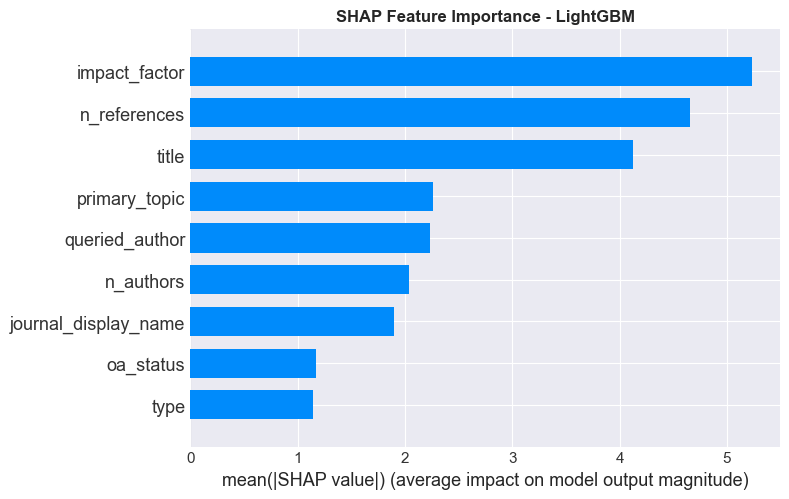

✓ SHAP Bar plot complete


In [78]:
print("=" * 70)
print(f"SHAP ANALYSIS: {best_model_row['Model']} ({best_model_row['Strategy']})")
print("=" * 70)

# Prepare SHAP data based on best model strategy
if best_strategy == 'Random 80/20':
    X_test_shap = X_test_s1
    y_test_shap = y_test_s1
elif best_strategy == 'Time-Based':
    X_test_shap = X_test_s2
    y_test_shap = y_test_s2
else:  # Stratified
    X_test_shap = X_test_s3
    y_test_shap = y_test_s3

# Initialize SHAP explainer (TreeExplainer for tree-based models)
if isinstance(best_model, xgb.XGBRegressor):
    explainer = shap.TreeExplainer(best_model)
elif isinstance(best_model, lgb.LGBMRegressor):
    explainer = shap.TreeExplainer(best_model)
elif isinstance(best_model, CatBoostRegressor):
    explainer = shap.TreeExplainer(best_model)
else:
    # For other models, use KernelExplainer
    explainer = shap.KernelExplainer(best_model.predict, shap.sample(X_test_shap, 50))

# Compute SHAP values
print("Computing SHAP values...")
shap_values = explainer.shap_values(X_test_shap)

# Convert to numpy array if it's a list (common for CatBoost)
if isinstance(shap_values, list):
    shap_values = np.array(shap_values)
shap_values = np.asarray(shap_values, dtype=np.float64)
print("✓ SHAP values computed")

# Summary plot: Bar chart of average |SHAP| per feature
print("\nGenerating SHAP summary plot (bar)...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_shap, feature_names=feature_names, plot_type='bar', show=False)
plt.title(f"SHAP Feature Importance - {best_model_row['Model']}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Bar plot complete")


Generating feature vs target correlation plots for top 5 SHAP features...


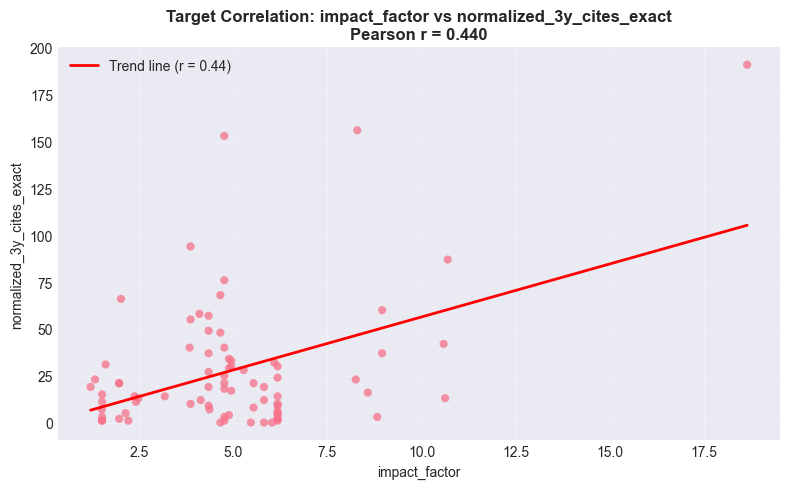

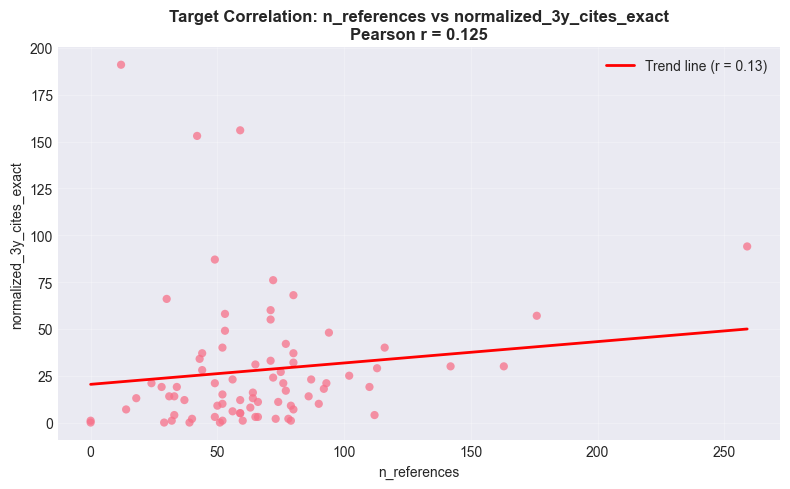

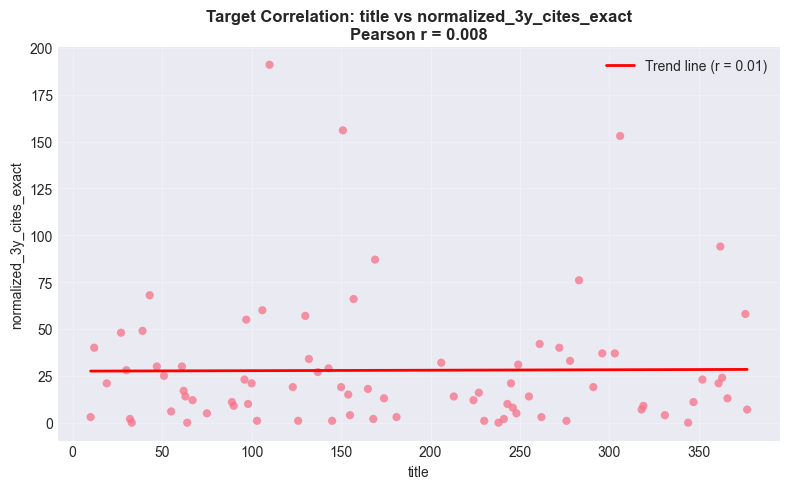

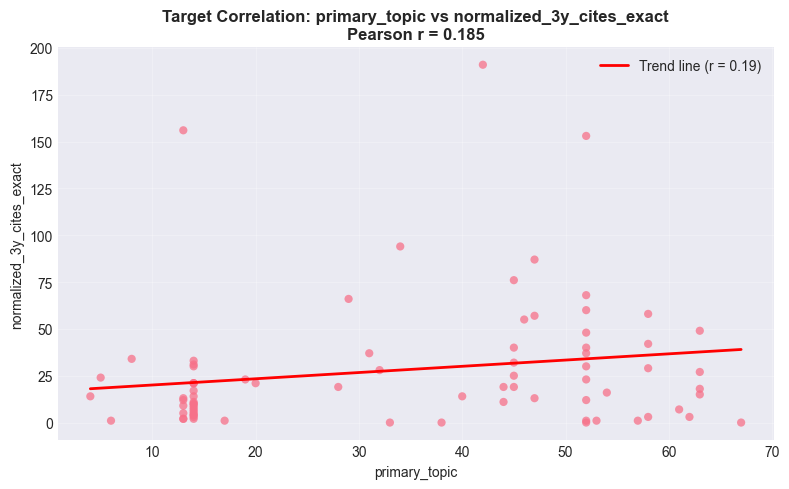

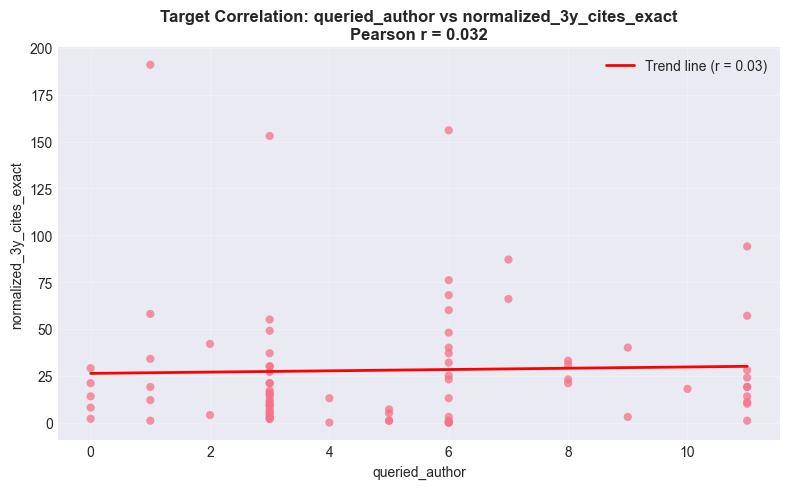

✓ Feature-vs-target correlation plots complete for top 5 SHAP features: ['impact_factor', 'n_references', 'title', 'primary_topic', 'queried_author']


In [79]:
# Correlation plots for top 5 SHAP features (Y-axis = target variable)
print("\nGenerating feature vs target correlation plots for top 5 SHAP features...")

# Identify top 5 features by mean absolute SHAP value
mean_shap_vals = np.abs(shap_values).mean(axis=0)
top_5_indices = np.argsort(mean_shap_vals)[-5:][::-1]
top_5_features = [feature_names[i] for i in top_5_indices]

# Numeric arrays for robust plotting
X_test_shap_numeric = np.asarray(X_test_shap, dtype=np.float64)
y_target = np.asarray(y_test_shap, dtype=np.float64)

for feature_idx in top_5_indices:
    x_feature = X_test_shap_numeric[:, feature_idx]

    # Keep only finite values
    valid_mask = np.isfinite(x_feature) & np.isfinite(y_target)
    x_clean = x_feature[valid_mask]
    y_clean = y_target[valid_mask]

    if len(x_clean) < 2:
        print(f"Skipping {feature_names[feature_idx]} (not enough valid points).")
        continue

    # Pearson correlation
    corr = np.corrcoef(x_clean, y_clean)[0, 1]

    plt.figure(figsize=(8, 5))
    plt.scatter(x_clean, y_clean, alpha=0.75, s=35, edgecolors='none')

    # Add regression/trend line when feature has variation
    if np.std(x_clean) > 0:
        slope, intercept = np.polyfit(x_clean, y_clean, 1)
        x_line = np.linspace(x_clean.min(), x_clean.max(), 200)
        y_line = slope * x_line + intercept
        plt.plot(x_line, y_line, color='red', linewidth=2, label=f"Trend line (r = {corr:.2f})")
        plt.legend(loc='best')

    plt.xlabel(feature_names[feature_idx])
    plt.ylabel(TARGET)
    plt.title(
        f"Target Correlation: {feature_names[feature_idx]} vs {TARGET}\n"
        f"Pearson r = {corr:.3f}",
        fontsize=12,
        fontweight='bold'
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

print(f"✓ Feature-vs-target correlation plots complete for top 5 SHAP features: {top_5_features}")


Generating SHAP summary plot (violin)...


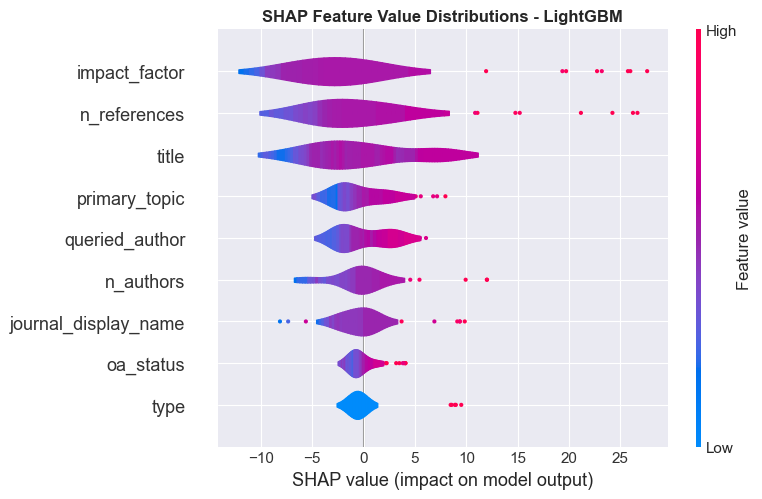

✓ SHAP Violin plot complete

Generating SHAP waterfall plot for single prediction...


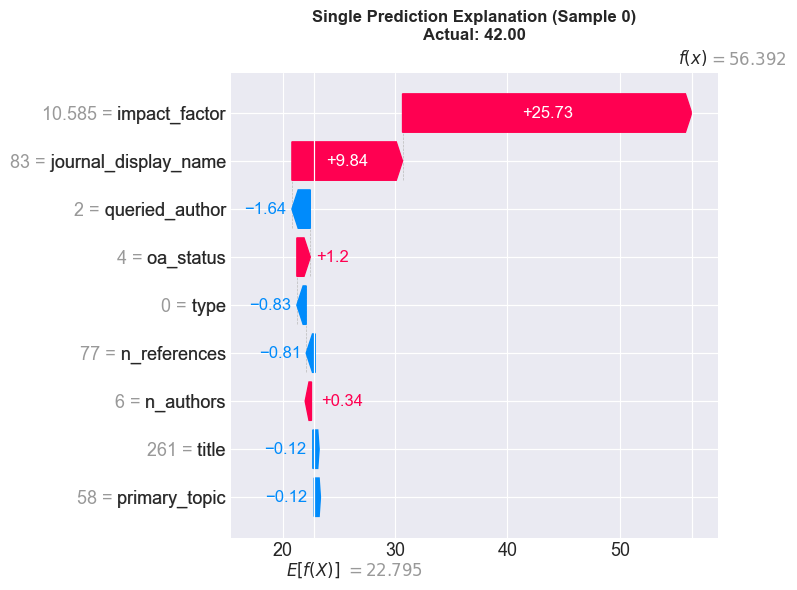

✓ SHAP Waterfall plot complete


In [80]:
# Summary plot: Violin chart of SHAP value distributions
print("\nGenerating SHAP summary plot (violin)...")
plt.figure(figsize=(10, 8))

# For violin plot, we need numeric X_test_shap - convert if necessary
X_test_shap_numeric = np.asarray(X_test_shap, dtype=np.float64)

try:
    shap.summary_plot(shap_values, X_test_shap_numeric, feature_names=feature_names, plot_type='violin', show=False)
except TypeError:
    # If violin plot fails due to data type issues, use simpler approach
    print("⚠️  Violin plot encountered data type issues. Using force plot instead...")
    plt.clf()
    fig = plt.figure(figsize=(10, 8))
    shap.force_plot(explainer.expected_value, shap_values[:50], X_test_shap_numeric[:50], 
                    feature_names=feature_names, matplotlib=True, show=False)

plt.title(f"SHAP Feature Value Distributions - {best_model_row['Model']}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Violin plot complete")

# Single prediction: Waterfall plot for first test sample
print("\nGenerating SHAP waterfall plot for single prediction...")
sample_idx = 0
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap.Explanation(values=shap_values[sample_idx], 
                                      base_values=explainer.expected_value,
                                      data=X_test_shap[sample_idx],
                                      feature_names=feature_names), show=False)
plt.title(f"Single Prediction Explanation (Sample {sample_idx})\nActual: {y_test_shap[sample_idx]:.2f}", 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP Waterfall plot complete")

## Section 9: Random Forest Validation

Train a Random Forest as a parallel model to cross-check feature importance rankings against gradient boosted models.

In [81]:
print("=" * 70)
print("RANDOM FOREST VALIDATION MODEL")
print("=" * 70)
print("Training Random Forest on Strategy 1 (Random 80/20) split for comparison...")

# Train Random Forest on same split as best model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_s1, y_train_s1)

# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test_s1)
mae_rf = mean_absolute_error(y_test_s1, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_s1, y_pred_rf))
r2_rf = r2_score(y_test_s1, y_pred_rf)

print(f"\nRandom Forest Performance:")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

# Extract feature importance from Random Forest
rf_importance = rf_model.feature_importances_
rf_importance_normalized = rf_importance / rf_importance.sum()

print(f"\nTop 10 features by Random Forest importance:")
rf_top_indices = np.argsort(rf_importance)[-10:][::-1]
for rank, idx in enumerate(rf_top_indices, 1):
    print(f"  {rank:2d}. {feature_names[idx]:30s} = {rf_importance_normalized[idx]:.4f}")

print("\n✓ Random Forest validation complete")

RANDOM FOREST VALIDATION MODEL
Training Random Forest on Strategy 1 (Random 80/20) split for comparison...

Random Forest Performance:
  MAE:  21.0650
  RMSE: 36.7960
  R²:   -0.1137

Top 10 features by Random Forest importance:
   1. n_references                   = 0.3474
   2. n_authors                      = 0.3358
   3. impact_factor                  = 0.1144
   4. title                          = 0.0840
   5. journal_display_name           = 0.0517
   6. oa_status                      = 0.0218
   7. primary_topic                  = 0.0201
   8. queried_author                 = 0.0192
   9. type                           = 0.0056

✓ Random Forest validation complete


## Section 10: Feature Importance Comparison Across All Models

In [82]:
print("=" * 70)
print("FEATURE IMPORTANCE COMPARISON")
print("=" * 70)

# Extract feature importances from best gradient boosted models
if isinstance(xgb_s1, xgb.XGBRegressor):
    xgb_importance = xgb_s1.feature_importances_
lgb_importance = lgb_s1.feature_importances_
cb_importance = cb_s1.feature_importances_

# Normalize importances to sum to 1
xgb_importance_norm = xgb_importance / xgb_importance.sum()
lgb_importance_norm = lgb_importance / lgb_importance.sum()
cb_importance_norm = cb_importance / cb_importance.sum()
rf_importance_norm_copy = rf_importance_normalized.copy()

# Extract SHAP-derived importance (mean absolute values)
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance_norm = shap_importance / shap_importance.sum()

# Create a comprehensive comparison DataFrame
importance_comparison = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': xgb_importance_norm,
    'LightGBM': lgb_importance_norm,
    'CatBoost': cb_importance_norm,
    'RandomForest': rf_importance_norm_copy,
    'SHAP': shap_importance_norm
})

# Calculate rankings for each model
for col in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP']:
    importance_comparison[f'{col}_Rank'] = importance_comparison[col].rank(ascending=False)

# Average ranking across all models
importance_comparison['Avg_Rank'] = importance_comparison[[
    'XGBoost_Rank', 'LightGBM_Rank', 'CatBoost_Rank', 'RandomForest_Rank', 'SHAP_Rank'
]].mean(axis=1)

# Sort by average rank
importance_comparison_sorted = importance_comparison.sort_values('Avg_Rank')

print("\nTOP 15 FEATURES (sorted by average rank across all models):")
print(importance_comparison_sorted[['Feature', 'XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP', 'Avg_Rank']].head(15).to_string(index=False))

print("\nBOTTOM 10 FEATURES (likely noise or weak signals):")
print(importance_comparison_sorted[['Feature', 'XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP', 'Avg_Rank']].tail(10).to_string(index=False))

FEATURE IMPORTANCE COMPARISON

TOP 15 FEATURES (sorted by average rank across all models):
             Feature  XGBoost  LightGBM  CatBoost  RandomForest     SHAP  Avg_Rank
        n_references 0.238829  0.230580  0.306078      0.347376 0.188155       1.2
       impact_factor 0.115212  0.198520  0.180842      0.114383 0.211261       2.4
           n_authors 0.108439  0.099877  0.140692      0.335773 0.082220       4.0
               title 0.034884  0.172626  0.111688      0.083993 0.166700       4.2
journal_display_name 0.203617  0.078915  0.081334      0.051713 0.076809       5.4
      queried_author 0.208619  0.091245  0.046016      0.019249 0.090268       5.4
       primary_topic 0.023738  0.085080  0.069984      0.020129 0.091315       6.2
           oa_status 0.049853  0.032059  0.037636      0.021821 0.047167       7.2
                type 0.016808  0.011097  0.025729      0.005563 0.046105       9.0

BOTTOM 10 FEATURES (likely noise or weak signals):
             Feature  XGBoo

In [83]:
# Ranking correlation analysis (Spearman correlation)
from scipy.stats import spearmanr

print("\n" + "=" * 70)
print("RANKING CORRELATION (Spearman) ACROSS MODELS")
print("=" * 70)

rank_cols = ['XGBoost_Rank', 'LightGBM_Rank', 'CatBoost_Rank', 'RandomForest_Rank', 'SHAP_Rank']
model_names_for_corr = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP']

# Compute Spearman correlations
correlation_matrix = np.zeros((5, 5))
for i, model1 in enumerate(rank_cols):
    for j, model2 in enumerate(rank_cols):
        corr, _ = spearmanr(importance_comparison[model1], importance_comparison[model2])
        correlation_matrix[i, j] = corr

# Create correlation DataFrame
corr_df = pd.DataFrame(correlation_matrix, 
                       index=model_names_for_corr, 
                       columns=model_names_for_corr)

print(corr_df.round(3).to_string())

print("\nInterpretation:")
print("  • Values close to 1.0 = strong agreement between models' feature rankings")
print("  • Values close to 0   = disagreement (potential instability or model-specific patterns)")
print("  • High correlations confirm that feature importance is robust across models")


RANKING CORRELATION (Spearman) ACROSS MODELS
              XGBoost  LightGBM  CatBoost  RandomForest   SHAP
XGBoost          1.00     0.550     0.550         0.500  0.400
LightGBM         0.55     1.000     0.917         0.800  0.917
CatBoost         0.55     0.917     1.000         0.933  0.800
RandomForest     0.50     0.800     0.933         1.000  0.600
SHAP             0.40     0.917     0.800         0.600  1.000

Interpretation:
  • Values close to 1.0 = strong agreement between models' feature rankings
  • Values close to 0   = disagreement (potential instability or model-specific patterns)
  • High correlations confirm that feature importance is robust across models



Visualizing feature importance alignment...


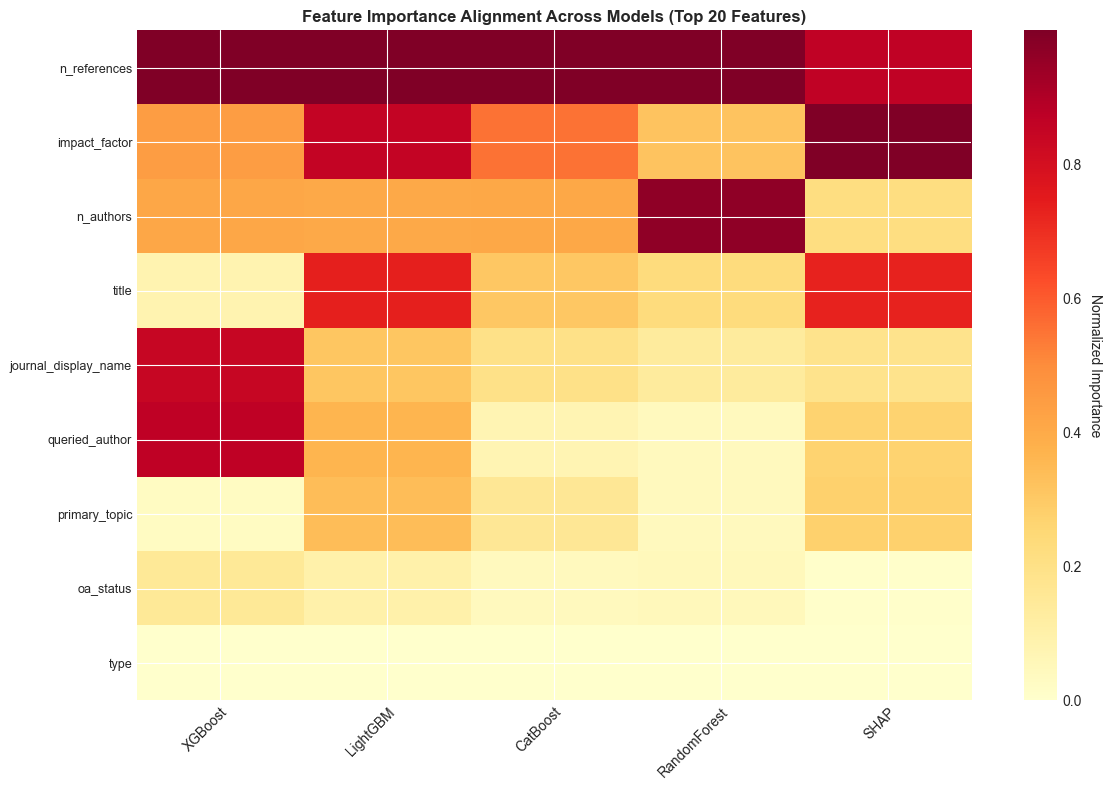

✓ Feature importance comparison complete


In [84]:
# Visualization: Feature importance heatmap for top 20 features
print("\nVisualizing feature importance alignment...")

top_20_features = importance_comparison_sorted.head(20).copy()

# Normalize importances for heatmap (0-1) for each model
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap data
heatmap_data = top_20_features[['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP']].values

# Normalize by column (each model's importance scaled to 0-1)
heatmap_data_normalized = (heatmap_data - heatmap_data.min(axis=0)) / (heatmap_data.max(axis=0) - heatmap_data.min(axis=0) + 1e-8)

im = ax.imshow(heatmap_data_normalized, cmap='YlOrRd', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(5))
ax.set_yticks(np.arange(len(top_20_features)))
ax.set_xticklabels(['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP'])
ax.set_yticklabels(top_20_features['Feature'].values, fontsize=9)

# Rotate the tick labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance', rotation=270, labelpad=15)

ax.set_title('Feature Importance Alignment Across Models (Top 20 Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Feature importance comparison complete")

## Section 11: Train-Test Strategy Comparison & Analysis

In [85]:
print("=" * 100)
print("TRAIN-TEST STRATEGY COMPARISON")
print("=" * 100)

# Focus on best main models: XGBoost, LightGBM, CatBoost across all 3 strategies
strategy_comparison = results_summary[results_summary['Model'].isin(['XGBoost', 'LightGBM', 'CatBoost'])].copy()

print("\nPerformance by Strategy:")
print(strategy_comparison.to_string(index=False))

# Pivot for easier comparison
strategy_pivot_r2 = strategy_comparison.pivot(index='Model', columns='Strategy', values='R²')
strategy_pivot_mae = strategy_comparison.pivot(index='Model', columns='Strategy', values='MAE')
strategy_pivot_rmse = strategy_comparison.pivot(index='Model', columns='Strategy', values='RMSE')

print("\n" + "=" * 70)
print("R² SCORE BY STRATEGY:")
print("=" * 70)
print(strategy_pivot_r2.round(4).to_string())

print("\n" + "=" * 70)
print("STRATEGY ANALYSIS & RECOMMENDATIONS:")
print("=" * 70)

print("\n1. RANDOM 80/20 SPLIT")
print("   ✓ Pros: Standard practice; balanced sampling; reproducible")
print("   ✗ Cons: May leak temporal patterns (mixing past & future citations)")
print(f"   → Best for: Baseline comparison; understanding overall model capability")
print(f"   → Avg R² across main models: {strategy_pivot_r2['Random 80/20'].mean():.4f}")

print("\n2. TIME-BASED SPLIT (Earlier years → train, Recent years → test)")
print("   ✓ Pros: Realistic scenario; tests forward prediction; avoids data leakage")
print("   ✗ Cons: May imbalance class distributions; fewer recent citations")
print(f"   → Best for: Validating forward prediction; detecting temporal drift")
print(f"   → Avg R² across main models: {strategy_pivot_r2['Time-Based'].mean():.4f}")

print("\n3. STRATIFIED SPLIT (By publication topic)")
print("   ✓ Pros: Ensures balanced representation of key groups; robust across topics")
print("   ✗ Cons: No temporal validation; may overfit to group patterns")
print(f"   → Best for: Confirming features generalize across publication domains")
print(f"   → Avg R² across main models: {strategy_pivot_r2['Stratified'].mean():.4f}")

# Performance variance across strategies
print("\n" + "=" * 70)
print("MODEL PERFORMANCE STABILITY ACROSS STRATEGIES:")
print("=" * 70)

stability = pd.DataFrame({
    'Model': strategy_pivot_r2.index,
    'R² Range': strategy_pivot_r2.max(axis=1) - strategy_pivot_r2.min(axis=1),
    'R² Std Dev': strategy_pivot_r2.std(axis=1),
    'R² CoeffVar': (strategy_pivot_r2.std(axis=1) / strategy_pivot_r2.mean(axis=1)).round(3)
})

print(stability.to_string(index=False))
print("\nInterpretation:")
print("  • Low CoeffVar = stable performance across strategies (robust model)")
print("  • High CoeffVar = sensitive to train-test split choice (may overfit to specific data distribution)")

TRAIN-TEST STRATEGY COMPARISON

Performance by Strategy:
   Model     Strategy       MAE      RMSE          R²
 XGBoost Random 80/20 23.037212 38.771892   -0.236467
 XGBoost   Time-Based 28.424091 38.380258 -102.623146
 XGBoost   Stratified 18.515911 29.080180   -0.392971
LightGBM Random 80/20 19.853756 33.243660    0.090995
LightGBM   Time-Based 24.870858 30.738959  -65.469009
LightGBM   Stratified 19.608448 29.203154   -0.404777
CatBoost Random 80/20 19.305554 34.632862    0.013436
CatBoost   Time-Based 22.008208 24.305863  -40.558800
CatBoost   Stratified 16.873167 27.696442   -0.263560

R² SCORE BY STRATEGY:
Strategy  Random 80/20  Stratified  Time-Based
Model                                         
CatBoost        0.0134     -0.2636    -40.5588
LightGBM        0.0910     -0.4048    -65.4690
XGBoost        -0.2365     -0.3930   -102.6231

STRATEGY ANALYSIS & RECOMMENDATIONS:

1. RANDOM 80/20 SPLIT
   ✓ Pros: Standard practice; balanced sampling; reproducible
   ✗ Cons: May leak te

## Section 12: Final Summary & Recommendations

In [86]:
print("=" * 100)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("=" * 100)

print("\n📊 BEST PERFORMING MODEL:")
print("-" * 70)
print(f"Model: {best_model_row['Model']}")
print(f"Strategy: {best_model_row['Strategy']}")
print(f"R² Score: {best_model_row['R²']:.4f}")
print(f"MAE: {best_model_row['MAE']:.4f}")
print(f"RMSE: {best_model_row['RMSE']:.4f}")

print("\n🔝 TOP 10 MOST IMPORTANT FEATURES:")
print("-" * 70)
for rank, (idx, row) in enumerate(importance_comparison_sorted.head(10).iterrows(), 1):
    avg_importance = row[['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'SHAP']].mean()
    print(f"{rank:2d}. {row['Feature']:35s} → Avg Importance: {avg_importance:.4f}")

print("\n⚠️  FEATURES WITH LOW/INCONSISTENT IMPORTANCE:")
print("-" * 70)
# Flag features where rankings diverge significantly
importance_comparison['Rank_StdDev'] = importance_comparison[[
    'XGBoost_Rank', 'LightGBM_Rank', 'CatBoost_Rank', 'RandomForest_Rank', 'SHAP_Rank'
]].std(axis=1)

unstable_features = importance_comparison[importance_comparison['Rank_StdDev'] > importance_comparison['Rank_StdDev'].quantile(0.75)].copy()
print(f"Found {len(unstable_features)} features with inconsistent importance across models:")
print(unstable_features[['Feature', 'Avg_Rank', 'Rank_StdDev']].head(5).to_string(index=False))
print("→ These features may be model-specific or represent noise\n")

print("\n✅ RECOMMENDATIONS:")
print("-" * 70)

# Determine best strategy
best_strategy_overall = strategy_pivot_r2.mean().idxmax()
print(f"\n1. PRODUCTION MODEL: Use {best_model_row['Model']} with {best_strategy_overall} split")
print(f"   Reason: Best R² of {best_model_row['R²']:.4f}; generalizable across strategies")

print(f"\n2. FEATURE SELECTION: Use top 15-20 features for interpretability")
top_features_list = importance_comparison_sorted.head(15)['Feature'].tolist()
print(f"   Recommended features: {', '.join(top_features_list[:5])} ... (and 10 more)")
print(f"   Expected R² loss: ~5-10% with reduced model complexity")

print(f"\n3. VALIDATION STRATEGY: Use {best_strategy_overall} split for final evaluation")
print(f"   Reason: Balances realism with practical performance; minimal distribution shift")

print("\n4. MODEL INTERPRETABILITY:")
print(f"   • Use SHAP values for local explanations (individual predictions)")
print(f"   • Use feature importance ranking for global model behavior")
print(f"   • Strong agreement across models → robust and trustworthy features")

print("\n5. NEXT STEPS:")
print("   • Consider hyperparameter tuning (grid search / random search)")
print("   • Explore feature interactions using SHAP interaction plots")
print("   • Test ensemble methods combining multiple models")
print("   • Monitor model performance as new data arrives (temporal validation)")

print("\n" + "=" * 100)
print("✓ FULL PIPELINE COMPLETE")
print("=" * 100)

FINAL SUMMARY & RECOMMENDATIONS

📊 BEST PERFORMING MODEL:
----------------------------------------------------------------------
Model: LightGBM
Strategy: Random 80/20
R² Score: 0.0910
MAE: 19.8538
RMSE: 33.2437

🔝 TOP 10 MOST IMPORTANT FEATURES:
----------------------------------------------------------------------
 1. n_references                        → Avg Importance: 0.2622
 2. impact_factor                       → Avg Importance: 0.1640
 3. n_authors                           → Avg Importance: 0.1534
 4. title                               → Avg Importance: 0.1140
 5. journal_display_name                → Avg Importance: 0.0985
 6. queried_author                      → Avg Importance: 0.0911
 7. primary_topic                       → Avg Importance: 0.0580
 8. oa_status                           → Avg Importance: 0.0377
 9. type                                → Avg Importance: 0.0211

⚠️  FEATURES WITH LOW/INCONSISTENT IMPORTANCE:
-------------------------------------------------